### **Data Cleaning**

In [ ]:
import pandas as pd
import numpy as np
import re

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('Region_summary_NSW.csv')

# Display the first 5 rows of the DataFrame to verify it loaded correctly
display(df.shape)
display(df.head())
display(df.info())

(800, 15)

,Measure Code,Parent Description,Description,2011,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,ERP_P_20,Estimated resident population - year ended 30 ...,Estimated resident population (no.),NaN,NaN,NaN,NaN,NaN,8046748.0,8110610.0,8097062.0,8166704.0,8341199.0,8479314.0,NaN
1,ERP_21,Estimated resident population - year ended 30 ...,Population density (persons/km2),NaN,NaN,NaN,NaN,NaN,10.0,10.1,10.1,10.2,10.4,10.6,NaN
2,ERP_M_20,Estimated resident population - year ended 30 ...,Estimated resident population - males (no.),NaN,NaN,NaN,NaN,NaN,3999452.0,4030710.0,4025393.0,4059763.0,4149032.0,4217861.0,NaN
3,ERP_F_20,Estimated resident population - year ended 30 ...,Estimated resident population - females (no.),NaN,NaN,NaN,NaN,NaN,4047296.0,4079900.0,4071669.0,4106941.0,4192167.0,4261453.0,NaN
4,ERP_19,Estimated resident population - year ended 30 ...,Median age - males (years),NaN,NaN,NaN,NaN,NaN,36.8,37.2,37.7,37.7,37.5,37.5,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Measure Code        800 non-null    object 
 1   Parent Description  800 non-null    object 
 2   Description         800 non-null    object 
 3   2011                259 non-null    float64
 4   2015                20 non-null     float64
 5   2016                457 non-null    float64
 6   2017                48 non-null     float64
 7   2018                125 non-null    float64
 8   2019                270 non-null    float64
 9   2020                291 non-null    float64
 10  2021                692 non-null    float64
 11  2022                293 non-null    float64
 12  2023                207 non-null    float64
 13  2024                209 non-null    float64
 14  2025                3 non-null      float64
dtypes: float64(12), object(3)
memory usage: 93.9+ KB


None

In [ ]:
# CLEAN: drop COLUMN years with less than 100 non-nulls
# df_clean = df.dropna(axis=1, thresh=100)
df_clean = df.drop(columns=['2015', '2017', '2025'])

# Melt from wide to long format for easier analysis (every row is one observation, a single matric for a single year)
#easier to filter, group and plot
df_long = df_clean.melt(
    id_vars=['Measure Code', 'Parent Description', 'Description'],
    var_name='Year',
    value_name='Value'
)
# Drop rows with no data
df_long = df_long.dropna(subset=['Value'])

# column simple rename
df_long = df_long.rename(columns={
    "Measure Code": "code",
    "Parent Description": "category",
    "Description": "metric",
    "Year": "year",
    "Value": "value"
})

# strip whitespace from all string columns
df_long['code'] = df_long['code'].str.strip()
df_long['metric'] = df_long['metric'].str.strip()
df_long['category'] = df_long['category'].str.strip()

# convert row values to numeric data type for sorting / plotting
df_long['year'] = df_long['year'].astype(int)
df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")

# drop duplicates (just incase -> gov data sometimes repeats)
df_long = df_long.drop_duplicates(
    subset=["code", "metric", "year"]
)

# only keep data with at least 3 distinct years (fewer don't have enough to observe a trend)
# 1 can't say anything, 2 can say its going up or down, 3 can say consistenly rising and falling
counts = df_long.groupby("metric")["year"].nunique() #count the distinct data points per metrics
valid_metrics = counts[counts >= 3].index #find the matric with more than 3
df_long = df_long[df_long["metric"].isin(valid_metrics)] #keep only the rows in valid_metrics

#extract unit for matrix name: V
def extract_unit(metric: str) -> str:
    m = re.search(r"\(([^)]+)\)\s*$", metric)
    if m:
        return m.group(1).strip()
    if metric.strip().startswith("%"):
        return "%"
    if re.match(r"^Number of", metric, re.IGNORECASE):
        return "no."
    return "other"

df_long["unit"] = df_long["metric"].apply(extract_unit)

#concise name
def clean_metric(metric: str) -> str:
    s = re.sub(r"\s*\([^)]+\)\s*$", "", metric).strip()
    if len(s) > 60:
        s = s[:57].rsplit(" ", 1)[0] + "..."
    return s

df_long["metric"] = df_long["metric"].apply(clean_metric)

# SORT: Order by indicator (measure code) then year + reset indexing
# this sorting shows progression over years (min 3 yrs) for each metric
df_long = df_long.sort_values(["metric", "year"]).reset_index(drop=True)


# save cleaned dataset
df_long.to_csv("NSW_region_cleaned.csv", index=False)

# display cleaned data
print(f"Total processed rows: {len(df_long)}")
display(df_long.head())
# display(df.info())

Total processed rows: 2524


,code,category,metric,year,value,unit
0,ING_EMP3,Labour force status - Census,% of total Census responding population employed,2011,46.8,%
1,ING_EMP3,Labour force status - Census,% of total Census responding population employed,2016,50.4,%
2,ING_EMP3,Labour force status - Census,% of total Census responding population employed,2021,56.4,%
3,ING_HMLSS2,Homelessness - Census estimates of homelessness,% of total homeless or likely to be homeless p...,2011,8.0,%
4,ING_HMLSS2,Homelessness - Census estimates of homelessness,% of total homeless or likely to be homeless p...,2016,6.0,%


### **Statistics 1 - Migration Dependency  Index (MDI)**
What share of total population growth is driven by overseas migration alone?

#### Formula
MDI = Net Overseas Migration / Total Growth × 100
The percentage of total population growth attributable to overseas migration.
- MDI > 100% means overseas migration is compensating for losses elsewhere.
- MDI < 0%   means overseas migration is negative (border closures, etc.)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Statistic 1: Migration Dependency Index (MDI)
      natural_increase  net_int_mig  net_os_mig  total_growth  MDI_%
year                                                                
2021           44807.0     -16822.0     -5940.0       22045.0  -26.9
2022           34904.0     -39335.0     69112.0       64681.0  106.9
2023           32496.0     -34158.0    177100.0      175438.0  100.9

  2021  MDI = -26.9%
  2022  MDI = +106.9%
  2023  MDI = +100.9%



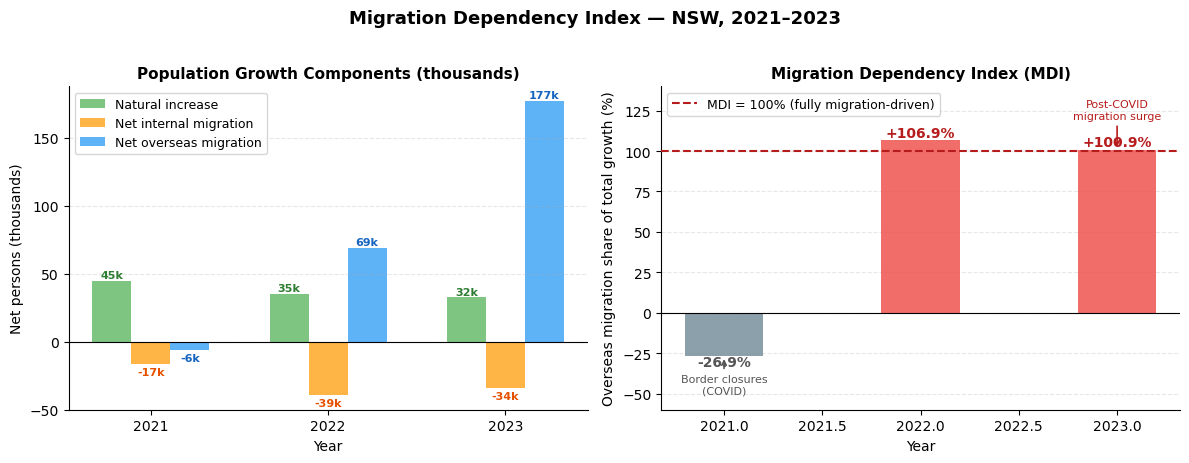

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv('NSW_region_cleaned.csv')

# Statstics 1: Migration Dependency Index (MDI)
births      = df[df['code'] == 'BD_2'].set_index('year')['value']
deaths      = df[df['code'] == 'BD_4'].set_index('year')['value']
net_int_mig = df[df['code'] == 'MIGRATION_4'].set_index('year')['value'] # arrivals minus departures within Australia
net_os_mig  = df[df['code'] == 'MIGRATION_7'].set_index('year')['value'] # overseas arrivals minus overseas departures
total_pop   = df[df['code'] == 'ERP_P_20'].set_index('year')['value']

mdi = pd.DataFrame({
    'births':      births,
    'deaths':      deaths,
    'net_int_mig': net_int_mig,
    'net_os_mig':  net_os_mig,
    'total_pop':   total_pop
}).dropna()   # overlapping years: 2021–2023

#population growth from reproudction alone (ignoring migration)
mdi['natural_increase'] = mdi['births'] - mdi['deaths']
mdi['total_growth']     = mdi['natural_increase'] + mdi['net_int_mig'] + mdi['net_os_mig']

# MDI: overseas migration share of total growth (%)
mdi['MDI_%'] = (mdi['net_os_mig'] / mdi['total_growth'] * 100).round(1)

print("Statistic 1: Migration Dependency Index (MDI)")
print(mdi[['natural_increase','net_int_mig','net_os_mig','total_growth','MDI_%']].to_string())
print()
for yr, row in mdi.iterrows():
    print(f"  {yr}  MDI = {row['MDI_%']:+.1f}%")
print ()

# Figure — Statistic 1: Migration Dependency Index (MDI)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

years = mdi.index.tolist()
x     = range(len(years))
width = 0.22

# Left: stacked component bar chart
bars_ni  = ax1.bar([i - width for i in x], mdi['natural_increase'] / 1000,
                    width, label='Natural increase', color='#66BB6A', alpha=0.85)
bars_nim = ax1.bar([i for i in x], mdi['net_int_mig'] / 1000,
                    width, label='Net internal migration', color='#FFA726', alpha=0.85)
bars_nom = ax1.bar([i + width for i in x], mdi['net_os_mig'] / 1000,
                    width, label='Net overseas migration', color='#42A5F5', alpha=0.85)

for bars, col in [(bars_ni, '#2E7D32'), (bars_nim, '#E65100'), (bars_nom, '#1565C0')]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 h + (2 if h >= 0 else -8),
                 f'{h:.0f}k', ha='center', fontsize=8, color=col, fontweight='bold')

ax1.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax1.set_title('Population Growth Components (thousands)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Net persons (thousands)')
ax1.set_xticks(list(x))
ax1.set_xticklabels(years)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Right: MDI line with threshold bands
mdi_vals = mdi['MDI_%']
colors   = ['#EF5350' if v > 100 else '#42A5F5' if v >= 0 else '#78909C'
            for v in mdi_vals]

bars2 = ax2.bar(years, mdi_vals, color=colors, width=0.4, zorder=3, alpha=0.85)

ax2.axhline(100, color='#B71C1C', linewidth=1.5, linestyle='--',
            label='MDI = 100% (fully migration-driven)', zorder=4)
ax2.axhline(0,   color='black',   linewidth=0.8, linestyle='-', zorder=4)

for bar, val in zip(bars2, mdi_vals):
    ypos = val + 2 if val >= 0 else val - 6
    ax2.text(bar.get_x() + bar.get_width() / 2, ypos,
             f'{val:+.1f}%', ha='center', fontsize=10, fontweight='bold',
             color='#B71C1C' if val > 100 else '#1565C0' if val >= 0 else '#555555')

ax2.set_title('Migration Dependency Index (MDI)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Overseas migration share of total growth (%)')
ax2.set_ylim(-60, 140)
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Annotation callouts
ax2.annotate('Border closures\n(COVID)', xy=(2021, -26.9),
             xytext=(2021, -50), ha='center', fontsize=8, color='#555555',
             arrowprops=dict(arrowstyle='->', color='#555555', lw=1.2))
ax2.annotate('Post-COVID\nmigration surge', xy=(2023, 100.9),
             xytext=(2023, 120), ha='center', fontsize=8, color='#B71C1C',
             arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.2))

fig.suptitle('Migration Dependency Index — NSW, 2021–2023',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz1_mdi.png', dpi=150, bbox_inches='tight')
plt.show()

### **Statistics 2 - Aging Squeeze**
How many elderaly dependents there are compared to child dependents, relying on working population

#### Formula
Ageing Index = Elderly Dependency Rate / Child Dependency Rate
- Aging Index > 1: more elderly dependents than child dependents, working-age population bears greater aged-care pressure
- Aging Index < 1: more child dependents than elderly dependents, greater pressure on education and family services
- Aging Index = 1: child and elderly are equally dependent on working population

2. Ageing Squeeze — Elderly vs Child Dependency
      elderly_dep_%  child_dep_%  ageing_index
year                                          
2019          25.08        28.46         0.881
2020          25.86        28.46         0.909
2021          26.75        28.67         0.933
2022          27.15        28.49         0.953
2023          27.09        27.72         0.977
2024          27.32        27.12         1.007

  Ageing index trend: Rising: society ageing



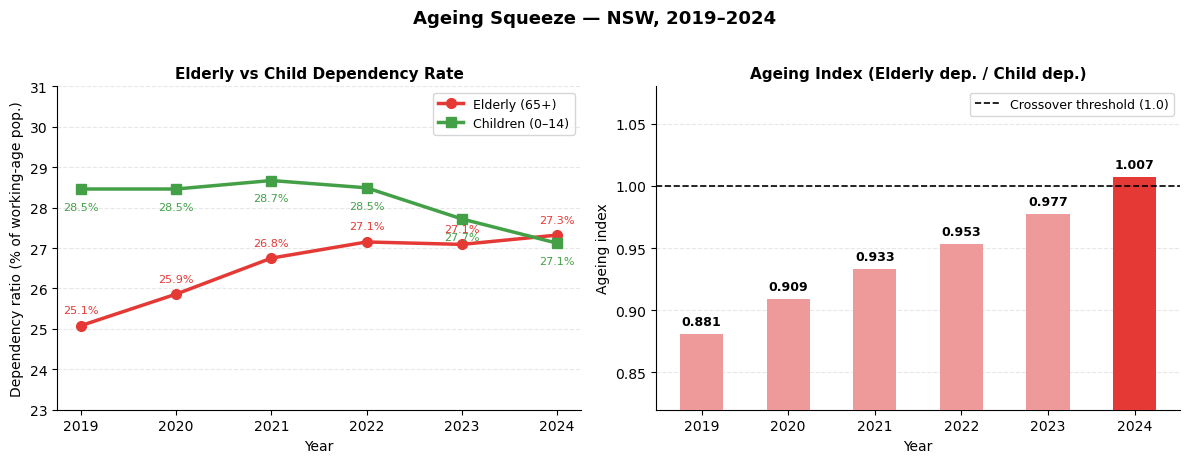

In [ ]:
#2. Aging Squeeze — Elderly vs Child Dependency over time
elderly_codes = ['ERP_P_15', 'ERP_P_16', 'ERP_P_17', 'ERP_P_18', 'ERP_P_19']
young_codes   = ['ERP_P_2', 'ERP_P_3', 'ERP_P_4']

elderly = df[df['code'].isin(elderly_codes)].groupby('year')['value'].sum()
young   = df[df['code'].isin(young_codes)].groupby('year')['value'].sum()
working = df[df['code'] == 'ERP_18'].groupby('year')['value'].sum()

elderly_dep = (elderly / working * 100).round(2)
child_dep   = (young   / working * 100).round(2)

squeeze = pd.DataFrame({
    'elderly_dep_%': elderly_dep,
    'child_dep_%':   child_dep
}).dropna()

squeeze['ageing_index'] = (squeeze['elderly_dep_%'] / squeeze['child_dep_%']).round(3)

print("2. Ageing Squeeze — Elderly vs Child Dependency")
print(squeeze.to_string())

direction = "Rising: society ageing" if squeeze['ageing_index'].iloc[-1] > squeeze['ageing_index'].iloc[0] else "FALLING ↓"
print(f"\n  Ageing index trend: {direction}") # ageing index > 1 means more elderly dependants than child dependants
print()

#figure

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

years = squeeze.index.tolist()

# Left panel: dependency rates
ax1.plot(years, squeeze['elderly_dep_%'], marker='o', color='#E53935',
         linewidth=2.5, markersize=7, label='Elderly (65+)')
ax1.plot(years, squeeze['child_dep_%'], marker='s', color='#43A047',
         linewidth=2.5, markersize=7, label='Children (0–14)')

for y, e, c in zip(years, squeeze['elderly_dep_%'], squeeze['child_dep_%']):
    ax1.annotate(f'{e:.1f}%', (y, e), textcoords='offset points',
                 xytext=(0, 9), ha='center', fontsize=8, color='#E53935')
    ax1.annotate(f'{c:.1f}%', (y, c), textcoords='offset points',
                 xytext=(0, -15), ha='center', fontsize=8, color='#43A047')

ax1.set_title('Elderly vs Child Dependency Rate', fontsize=11, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Dependency ratio (% of working-age pop.)')
ax1.set_ylim(23, 31)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Right panel: ageing index
bar_colors = ['#EF9A9A' if v < 1.0 else '#E53935' for v in squeeze['ageing_index']]
bars = ax2.bar(years, squeeze['ageing_index'], color=bar_colors,
               width=0.5, zorder=3)
ax2.axhline(1.0, color='black', linewidth=1.2, linestyle='--', zorder=4,
            label='Crossover threshold (1.0)')

for bar, val in zip(bars, squeeze['ageing_index']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Ageing Index (Elderly dep. / Child dep.)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Ageing index')
ax2.set_ylim(0.82, 1.08)
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle('Ageing Squeeze — NSW, 2019–2024', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz2_ageing_squeeze.png', dpi=150, bbox_inches='tight')
plt.show()


### **Statistics 3 - Workforce Pressure Index (WPI)**
Is NSW's workforce naturally replenishing itself, or is there labour gaps that requires external resources to fullfill?

#### Formula
Workforce Pressure Index (WPI) = Entrants (20–24) / Retirees (65–69)

- WPI > 1：more young people entering the workforce than older people retiring; labour pipeline is healthy
- WPI = 1：breakeven; one entrant for every retiree
- WPI < 1： more retirees leaving than entrants arriving; labour shortage pressure building

3. Workforce Pressure Index 
      entrants_20_24  retirees_65_69  workforce_pressure_index
year                                                          
2019        549214.0        393734.0                    1.3949
2020        534467.0        403426.0                    1.3248
2021        506754.0        407740.0                    1.2428
2022        513740.0        413974.0                    1.2410
2023        548567.0        421392.0                    1.3018
2024        566556.0        430070.0                    1.3174

  Trend: Declining: labour shortage worsening



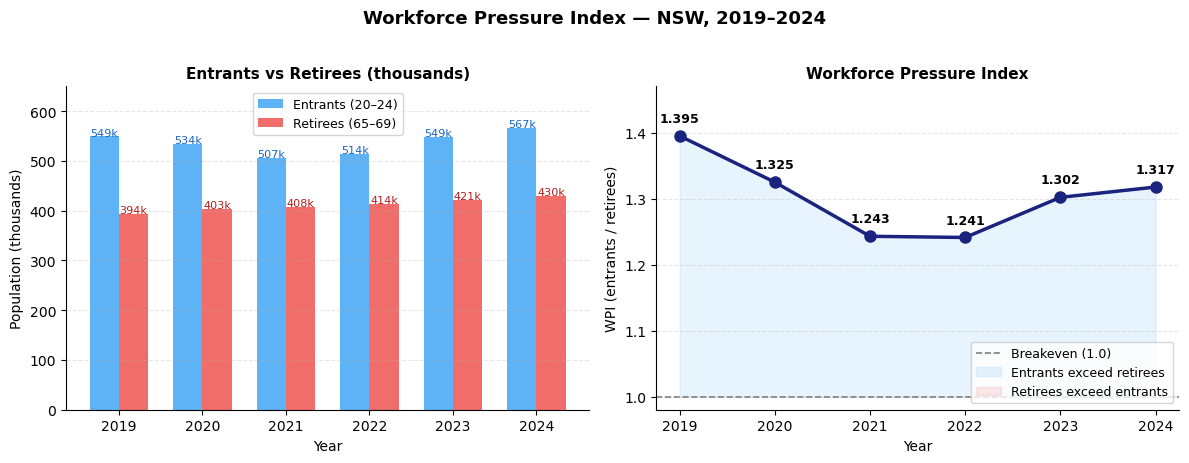

In [ ]:

# 3. Workforce Pressure Index

entrants = df[df['code'] == 'ERP_P_6'].set_index('year')['value']   # 20–24
retirees = df[df['code'] == 'ERP_P_15'].set_index('year')['value']  # 65–69

workforce = pd.DataFrame({
    'entrants_20_24': entrants,
    'retirees_65_69': retirees
}).dropna()

workforce['workforce_pressure_index'] = (
    workforce['entrants_20_24'] / workforce['retirees_65_69']
).round(4)

print("3. Workforce Pressure Index ")
print(workforce.to_string())

trend = workforce['workforce_pressure_index']
direction = "Declining: labour shortage worsening" if trend.iloc[-1] < trend.iloc[0] else "Rising: pipeline improving"
print(f"\n  Trend: {direction}")
print()

#figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

years = workforce.index.tolist()

# Left: grouped bars
x = range(len(years))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], workforce['entrants_20_24'] / 1000,
                width, label='Entrants (20–24)', color='#42A5F5', alpha=0.85)
bars2 = ax1.bar([i + width/2 for i in x], workforce['retirees_65_69'] / 1000,
                width, label='Retirees (65–69)', color='#EF5350', alpha=0.85)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
             f'{bar.get_height():.0f}k', ha='center', fontsize=8, color='#1565C0')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
             f'{bar.get_height():.0f}k', ha='center', fontsize=8, color='#B71C1C')

ax1.set_title('Entrants vs Retirees (thousands)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Population (thousands)')
ax1.set_xticks(list(x))
ax1.set_xticklabels(years)
ax1.set_ylim(0, 650)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Right: WPI line with threshold band
wpi = workforce['workforce_pressure_index']

ax2.plot(years, wpi, marker='o', color='#1A237E',
         linewidth=2.5, markersize=8, zorder=4)
ax2.axhline(1.0, color='gray', linewidth=1.2, linestyle='--', label='Breakeven (1.0)')
ax2.fill_between(years, 1.0, wpi,
                 where=wpi >= 1.0, alpha=0.12, color='#42A5F5',
                 label='Entrants exceed retirees')
ax2.fill_between(years, 1.0, wpi,
                 where=wpi < 1.0, alpha=0.12, color='#EF5350',
                 label='Retirees exceed entrants')

for y, v in zip(years, wpi):
    ax2.annotate(f'{v:.3f}', (y, v), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')

ax2.set_title('Workforce Pressure Index', fontsize=11, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('WPI (entrants / retirees)')
ax2.set_ylim(0.98, 1.47)
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax2.legend(fontsize=9, loc='lower right')
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle('Workforce Pressure Index — NSW, 2019–2024',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz3_workforce_pressure.png', dpi=150, bbox_inches='tight')
plt.show()

### **Statistics 4 - Household Framentation Index (HFI)**
Is NSW experiencing a structural shift away from traditional family households toward smaller, individual living arrangements?

#### Formula
(HFI) = Lone Person Rate × Childless Rate / Avg Children per Family

- Rising HFI — households are fragmenting; more people living alone, fewer children per family, more childless couples
- Falling HFI — households are consolidating; more family formation, higher birth rates
- HFI_pct_change — cumulative drift from 2011 baseline, shows acceleration or deceleration of fragmentation

Statistic 5: Household Fragmentation Index (HFI)
      lone_person_rate_%  childless_rate_%  avg_children      HFI  HFI_pct_change
year                                                                             
2011               24.24             36.57           1.9  466.556            0.00
2016               23.84             36.57           1.9  458.857           -1.65
2021               24.95             37.90           1.8  525.336           12.60

  2011  HFI = 466.556  (baseline)
  2016  HFI = 458.857  (-1.6%)
  2021  HFI = 525.336  (+12.6%)



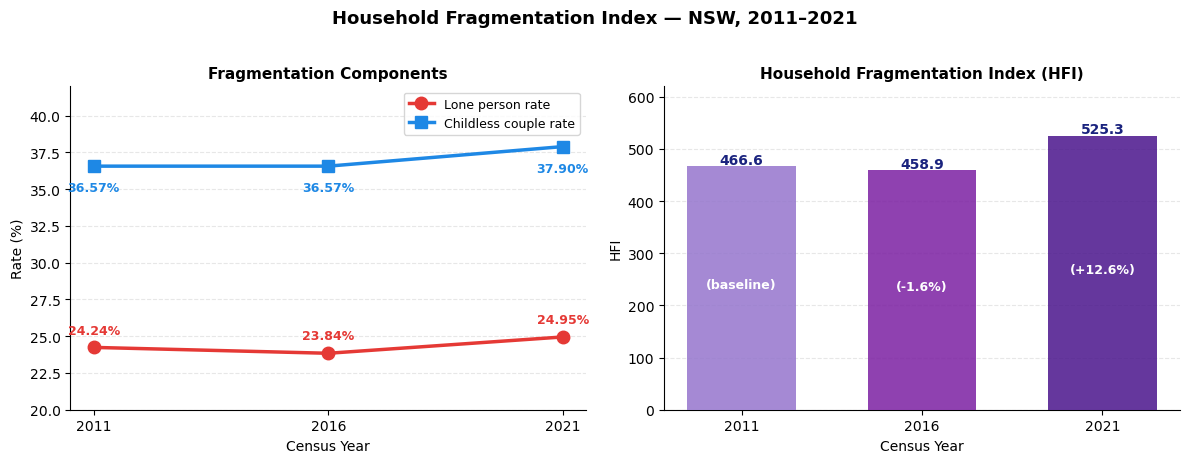

In [ ]:
# Statistic 4: Household Fragmentation Index (HFI)
lone_hh      = df[df['code'] == 'HHTYPE_2'].set_index('year')['value']   # lone person households
total_hh     = df[df['code'] == 'HHTYPE_5'].set_index('year')['value']   # total households
couple_no_ch = df[df['code'] == 'FAMILY_4'].set_index('year')['value']   # couple without children
total_fam    = df[df['code'] == 'FAMILY_8'].set_index('year')['value']   # total families
avg_children = df[df['code'] == 'CHILD_2'].set_index('year')['value']    # avg children per family

hfi = pd.DataFrame({
    'lone_hh':      lone_hh,
    'total_hh':     total_hh,
    'couple_no_ch': couple_no_ch,
    'total_fam':    total_fam,
    'avg_children': avg_children,
}).dropna()   # census years: 2011, 2016, 2021

# lone person rate: % of all households that are single-person
hfi['lone_person_rate_%'] = (hfi['lone_hh'] / hfi['total_hh'] * 100).round(2)

# childless couple rate: % of all families that are couples without children
hfi['childless_rate_%']   = (hfi['couple_no_ch'] / hfi['total_fam'] * 100).round(2)

# HFI: lone rate × childless rate / avg children per family
hfi['HFI'] = (hfi['lone_person_rate_%'] * hfi['childless_rate_%'] / hfi['avg_children']).round(3)

# cumulative change since 2011
hfi['HFI_pct_change'] = ((hfi['HFI'] / hfi['HFI'].iloc[0] - 1) * 100).round(2)

print("Statistic 5: Household Fragmentation Index (HFI)")
print(hfi[['lone_person_rate_%','childless_rate_%','avg_children','HFI','HFI_pct_change']].to_string())
print()
for yr, row in hfi.iterrows():
    change = f"({row['HFI_pct_change']:+.1f}%)" if yr > hfi.index[0] else "(baseline)"
    print(f"  {yr}  HFI = {row['HFI']:.3f}  {change}")

print()

# Figure — Statistic 4: Household Fragmentation Index (HFI)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

years = hfi.index.tolist()

# Left: component rates over census years
ax1.plot(years, hfi['lone_person_rate_%'], marker='o', color='#E53935',
         linewidth=2.5, markersize=9, label='Lone person rate')
ax1.plot(years, hfi['childless_rate_%'], marker='s', color='#1E88E5',
         linewidth=2.5, markersize=9, label='Childless couple rate')

for y, lv, cv in zip(years, hfi['lone_person_rate_%'], hfi['childless_rate_%']):
    ax1.annotate(f'{lv:.2f}%', (y, lv), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9, color='#E53935', fontweight='bold')
    ax1.annotate(f'{cv:.2f}%', (y, cv), textcoords='offset points',
                 xytext=(0, -18), ha='center', fontsize=9, color='#1E88E5', fontweight='bold')

ax1.set_title('Fragmentation Components', fontsize=11, fontweight='bold')
ax1.set_xlabel('Census Year')
ax1.set_ylabel('Rate (%)')
ax1.set_xticks(years)
ax1.set_ylim(20, 42)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Right: HFI bars with pct change labels
bar_colors = ['#9575CD', '#7B1FA2', '#4A148C']
bars = ax2.bar(years, hfi['HFI'], color=bar_colors, width=3, alpha=0.85, zorder=3)

for bar, val, pct, yr in zip(bars, hfi['HFI'], hfi['HFI_pct_change'], years):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             f'{val:.1f}', ha='center', fontsize=10, fontweight='bold', color='#1A237E')
    label = '(baseline)' if yr == years[0] else f'({pct:+.1f}%)'
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
             label, ha='center', fontsize=9, color='white', fontweight='bold')

ax2.set_title('Household Fragmentation Index (HFI)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Census Year')
ax2.set_ylabel('HFI')
ax2.set_xticks(years)
ax2.set_ylim(0, 620)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle('Household Fragmentation Index — NSW, 2011–2021',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz4_hfi.png', dpi=150, bbox_inches='tight')
plt.show()

### **Statistics 5 - Population Moemntum Index (PMI)**
Does NSW's age structure contain enough embedded growth to sustain its population naturally?

#### Formula
PMI = (Population 0-29 yrs old / Population 50+ yrs old) / (2.1 / TFR)

2.1 —> the standard demographic replacement fertility rate
TFR -> Total Fertaility Rate (Births per female)

2.1/TFR: correction ratio, if its tfr=2.1 giving the ratio of 1 then its replaceable
if bigger than one eg 1.4 it means young population needs to be 40% larger

- first part is age structure, multiplied by the ratio which tells you how far the population is from replacement

- PMI > 1 — young cohorts large enough to sustain structural growth; population can replenish itself despite below-replacement fertility
- PMI < 1 — age structure too top-heavy to replace itself; population growth becomes structurally contingent on migration
- PMI = 1 — structural breakeven; young and old cohorts exactly balanced relative to fertility


5. Population Momentum Index (PMI)
      young_0_29  old_50plus   TFR  tfr_gap     PMI  %_change
year                                                         
2019   3114655.0   2736530.0  1.77   1.1864  0.9594      0.00
2020   3090344.0   2801010.0  1.75   1.2000  0.9194     -4.17
2021   3030056.0   2847039.0  1.72   1.2209  0.8717     -9.14
2022   3054373.0   2886622.0  1.72   1.2209  0.8667     -9.66
2023   3141654.0   2928861.0  1.68   1.2500  0.8581    -10.56

  Status: PMI < 1: structural decline without migration
  Trend:  Declining ↓ momentum eroding



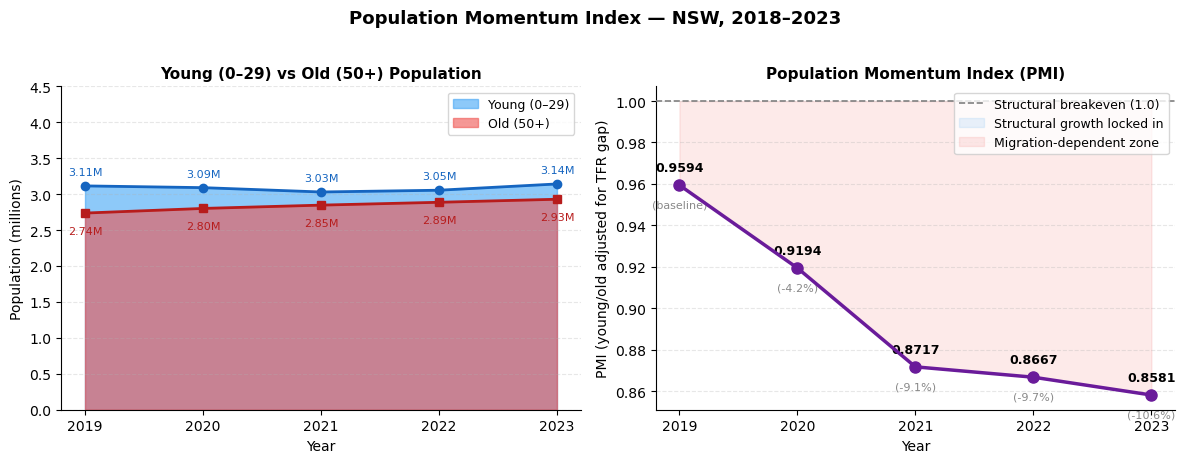

In [ ]:
# 5. Population Momentum Index (PMI)

young_codes = ['ERP_P_2','ERP_P_3','ERP_P_4','ERP_P_5','ERP_P_6','ERP_P_7']  # 0-29
old_codes   = ['ERP_P_12','ERP_P_13','ERP_P_14','ERP_P_15','ERP_P_16',
                'ERP_P_17','ERP_P_18','ERP_P_19']  # 50+

young = df[df['code'].isin(young_codes)].groupby('year')['value'].sum()
old   = df[df['code'].isin(old_codes)].groupby('year')['value'].sum()
tfr   = df[df['code'] == 'BD_3'].set_index('year')['value']

pmi = pd.DataFrame({
    'young_0_29': young,
    'old_50plus':  old,
    'TFR':         tfr,
}).dropna()

REPLACEMENT = 2.1
pmi['tfr_gap']  = (REPLACEMENT / pmi['TFR']).round(4)
pmi['PMI']      = (pmi['young_0_29'] / pmi['old_50plus'] / pmi['tfr_gap']).round(4)
pmi['%_change'] = ((pmi['PMI'] / pmi['PMI'].iloc[0] - 1) * 100).round(2) #all compared to 2019

print("5. Population Momentum Index (PMI)")
print(pmi[['young_0_29','old_50plus','TFR','tfr_gap','PMI','%_change']].to_string())

latest = pmi['PMI'].iloc[-1]
status = "PMI > 1: structural growth locked in" if latest > 1 else "PMI < 1: structural decline without migration"
trend  = "Declining ↓ momentum eroding" if pmi['PMI'].iloc[-1] < pmi['PMI'].iloc[0] else "Rising ↑"
print(f"\n  Status: {status}")
print(f"  Trend:  {trend}")
print()

# figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

years = pmi.index.tolist()

# Left: stacked area — young vs old population
ax1.fill_between(years, pmi['young_0_29'] / 1e6, alpha=0.6,
                 color='#42A5F5', label='Young (0–29)')
ax1.fill_between(years, pmi['old_50plus'] / 1e6, alpha=0.6,
                 color='#EF5350', label='Old (50+)')

ax1.plot(years, pmi['young_0_29'] / 1e6, marker='o', color='#1565C0', linewidth=2)
ax1.plot(years, pmi['old_50plus']  / 1e6, marker='s', color='#B71C1C', linewidth=2)

for y, yv, ov in zip(years, pmi['young_0_29']/1e6, pmi['old_50plus']/1e6):
    ax1.annotate(f'{yv:.2f}M', (y, yv), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8, color='#1565C0')
    ax1.annotate(f'{ov:.2f}M', (y, ov), textcoords='offset points',
                 xytext=(0, -15), ha='center', fontsize=8, color='#B71C1C')

ax1.set_title('Young (0–29) vs Old (50+) Population', fontsize=11, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Population (millions)')
ax1.set_ylim(0, 4.5)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Right: PMI line with threshold
ax2.plot(years, pmi['PMI'], marker='o', color='#6A1B9A',
         linewidth=2.5, markersize=8, zorder=4)
ax2.axhline(1.0, color='gray', linewidth=1.2, linestyle='--',
            label='Structural breakeven (1.0)', zorder=3)
ax2.fill_between(years, pmi['PMI'], 1.0,
                 where=pmi['PMI'] >= 1.0, alpha=0.12, color='#42A5F5',
                 label='Structural growth locked in')
ax2.fill_between(years, pmi['PMI'], 1.0,
                 where=pmi['PMI'] < 1.0, alpha=0.12, color='#EF5350',
                 label='Migration-dependent zone')

for y, v, p in zip(years, pmi['PMI'], pmi['%_change']):
    ax2.annotate(f'{v:.4f}', (y, v), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
    label = f'({p:+.1f}%)' if y > years[0] else '(baseline)'
    ax2.annotate(label, (y, v), textcoords='offset points',
                 xytext=(0, -16), ha='center', fontsize=8, color='#888888')

ax2.set_title('Population Momentum Index (PMI)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('PMI (young/old adjusted for TFR gap)')
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax2.legend(fontsize=9, loc='upper right')
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle('Population Momentum Index — NSW, 2018–2023',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz5_population_momentum.png', dpi=150, bbox_inches='tight')
plt.show()